# 06b. Model Comparison - Automobile Loan Default Prediction

Compares every candidate model using the cross-validation results logged in `experiments/results/`. All numbers come from stratified 5-fold CV on the training split at a 0.5 threshold. The held-out test set is not used in this notebook.


## 1. Setup


In [1]:
import os
import sys

project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

results_dir = "experiments/results" if os.path.exists("experiments/results") else "../experiments/results"


## 2. Collect Results

Results are read from three files: the shared log, the Logistic Regression file, and the XGBoost baseline-vs-tuned file. Duplicate rows for the same model keep the most recent entry. Each model has a protocol status: `verified` means its CV run is confirmed to match the shared protocol; `unverified` means the source still needs checking.


In [2]:
frames = [
    pd.read_csv(os.path.join(results_dir, "experiments.csv")),
    pd.read_csv(os.path.join(results_dir, "logistic_regression.csv")),
    pd.read_csv(os.path.join(results_dir, "xgboost_baseline_vs_tuned.csv")),
    pd.read_csv(os.path.join(results_dir, "lightgbm_baseline_vs_tuned.csv")),
]
all_results = pd.concat(frames, ignore_index=True).drop_duplicates(subset=['model_name'], keep='last')

PROTOCOL_STATUS = {
    "random_forest": "verified",
    "random_forest_tuned": "verified",
    "gaussian_naive_bayes": "verified",
    "logistic_regression": "verified",
    "XGBoost Baseline": "verified",
    "XGBoost Tuned": "verified",
    "LightGBM Baseline": "verified",
    "LightGBM Tuned": "verified",
    "decision_tree": "verified",
}
all_results["protocol_status"] = all_results["model_name"].map(PROTOCOL_STATUS).fillna("unknown")

print(all_results[['model_name', 'protocol_status', 'roc_auc_mean']].to_string(index=False))


          model_name protocol_status  roc_auc_mean
gaussian_naive_bayes        verified      0.696815
       decision_tree        verified      0.708183
 random_forest_tuned        verified      0.769818
       random_forest        verified      0.774053
 logistic_regression        verified      0.733998
    XGBoost Baseline        verified      0.763093
       XGBoost Tuned        verified      0.770509
   LightGBM Baseline        verified      0.748190
      LightGBM Tuned        verified      0.756597


## 3. Comparison Table

Ranking rule: take the model with the highest remaining mean ROC-AUC. Every model whose mean ROC-AUC is within one of that model's standard deviations joins its tier, because a gap smaller than the fold-to-fold spread is not a real difference. Inside a tier, models are ordered by PR-AUC. Repeat for the remaining models. Recall, precision and F1 are at 0.5.


In [3]:
def mean_pm_std(mean, std):
    return f"{mean:.3f} +/- {std:.3f}"


def rank_with_ties(results):
    remaining = results.sort_values("roc_auc_mean", ascending=False)
    tiers = []
    while not remaining.empty:
        leader = remaining.iloc[0]
        cutoff = leader["roc_auc_mean"] - leader["roc_auc_std"]
        in_tier = remaining[remaining["roc_auc_mean"] >= cutoff]
        tiers.append(in_tier.sort_values("pr_auc_mean", ascending=False).assign(tier=len(tiers) + 1))
        remaining = remaining.drop(in_tier.index)
    return pd.concat(tiers)


ranked = rank_with_ties(all_results)

table = pd.DataFrame({
    "tier": ranked["tier"],
    "model": ranked["model_name"],
    "ROC-AUC": [mean_pm_std(m, s) for m, s in zip(ranked["roc_auc_mean"], ranked["roc_auc_std"])],
    "PR-AUC": [mean_pm_std(m, s) for m, s in zip(ranked["pr_auc_mean"], ranked["pr_auc_std"])],
    "recall": ranked["recall_mean"].round(3),
    "precision": ranked["precision_mean"].round(3),
    "F1": ranked["f1_mean"].round(3),
    "threshold": ranked["threshold"].round(3),
    "protocol_status": ranked["protocol_status"],
}).reset_index(drop=True)
table.insert(0, "rank", range(1, len(table) + 1))
table


,rank,tier,model,ROC-AUC,PR-AUC,recall,precision,F1,threshold,protocol_status
0,1,1,random_forest,0.774 +/- 0.004,0.358 +/- 0.009,0.163,0.632,0.260,0.5,verified
1,2,1,XGBoost Tuned,0.771 +/- 0.004,0.307 +/- 0.009,0.045,0.717,0.085,0.5,verified
2,3,2,random_forest_tuned,0.770 +/- 0.004,0.339 +/- 0.009,0.285,0.381,0.326,0.5,verified
3,4,3,XGBoost Baseline,0.763 +/- 0.004,0.261 +/- 0.010,0.022,0.622,0.042,0.5,verified
4,5,4,LightGBM Tuned,0.757 +/- 0.004,0.248 +/- 0.013,0.560,0.203,0.298,0.5,verified
5,6,5,LightGBM Baseline,0.748 +/- 0.003,0.228 +/- 0.008,0.644,0.168,0.266,0.5,verified
6,7,6,logistic_regression,0.734 +/- 0.005,0.212 +/- 0.005,0.668,0.153,0.249,0.5,verified
7,8,7,decision_tree,0.708 +/- 0.004,0.181 +/- 0.004,0.607,0.152,0.242,0.5,verified
8,9,8,gaussian_naive_bayes,0.697 +/- 0.004,0.176 +/- 0.009,0.479,0.170,0.250,0.5,verified


## 4. Shortlisted Models: Out-of-Fold Predictions

The two tier-1 models are rebuilt and scored with the same stratified 5-fold split as `evaluate_model` (seed 42), on the training split only. Each row gets a predicted probability from the fold where it was held out. XGBoost Tuned is rebuilt from its saved best parameters with one thread, as in `07_hyperparameter_tuning.ipynb`, so its search is not re-run.

As a check, each model's mean per-fold ROC-AUC and PR-AUC are compared with the logged values. Random Forest must match exactly. XGBoost results vary slightly with the machine and the number of threads, so it must agree within one logged standard deviation, and the difference is shown.


In [4]:
import numpy as np
from sklearn.base import clone
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

from src.config import RANDOM_STATE, TARGET
from src.data.data_cleaning import clean_and_split
from src.models.random_forest import build_random_forest_pipeline
from src.models.xgboost_model import build_xgboost
from src.preprocessing.feature_engineering import build_pipeline

train_df, _ = clean_and_split()  # held-out test rows are discarded here
X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]

INTEGER_PARAMS = {"model__n_estimators", "model__max_depth"}
xgb_params = pd.read_csv(os.path.join(results_dir, "xgboost_best_parameters.csv"))
xgb_params = {
    row.parameter: int(row.value) if row.parameter in INTEGER_PARAMS else float(row.value)
    for row in xgb_params.itertuples()
}

shortlist = {
    "random_forest": build_random_forest_pipeline(),
    "XGBoost Tuned": build_pipeline(build_xgboost()).set_params(**xgb_params, model__n_jobs=1),
}
print("XGBoost Tuned parameters:", xgb_params)


XGBoost Tuned parameters: {'model__subsample': 0.7, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.01, 'model__n_estimators': 700, 'model__min_child_weight': 1.0, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__gamma': 0.5, 'model__colsample_bytree': 0.8}


In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
folds = list(skf.split(X_train, y_train))

oof = pd.DataFrame({"y_true": y_train.to_numpy(), "fold": -1})
for fold, (_, val_idx) in enumerate(folds):
    oof.loc[val_idx, "fold"] = fold

check_rows = []
for name, pipeline in shortlist.items():
    proba = np.zeros(len(y_train))
    fold_roc, fold_pr = [], []
    for train_idx, val_idx in folds:
        fold_model = clone(pipeline).fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        proba[val_idx] = fold_model.predict_proba(X_train.iloc[val_idx])[:, 1]
        fold_roc.append(roc_auc_score(y_train.iloc[val_idx], proba[val_idx]))
        fold_pr.append(average_precision_score(y_train.iloc[val_idx], proba[val_idx]))
    oof[name] = proba

    logged = all_results.set_index("model_name").loc[name]
    check_rows.append({
        "model": name,
        "roc_auc (recomputed)": np.mean(fold_roc),
        "roc_auc (logged)": logged["roc_auc_mean"],
        "pr_auc (recomputed)": np.mean(fold_pr),
        "pr_auc (logged)": logged["pr_auc_mean"],
    })

check = pd.DataFrame(check_rows)
check["roc_auc diff"] = check["roc_auc (recomputed)"] - check["roc_auc (logged)"]
check["pr_auc diff"] = check["pr_auc (recomputed)"] - check["pr_auc (logged)"]
# Random Forest must reproduce exactly; XGBoost within one logged standard deviation
TOLERANCE = {
    "random_forest": (1e-9, 1e-9),
    "XGBoost Tuned": tuple(all_results.set_index("model_name").loc["XGBoost Tuned", ["roc_auc_std", "pr_auc_std"]]),
}
check["within tolerance"] = [
    abs(r["roc_auc diff"]) <= TOLERANCE[r["model"]][0] and abs(r["pr_auc diff"]) <= TOLERANCE[r["model"]][1]
    for _, r in check.iterrows()
]
assert check["within tolerance"].all(), "recomputed scores do not agree with the log"

oof_path = os.path.join(results_dir, "shortlist_oof_predictions.csv")
oof.to_csv(oof_path, index=False)
print(f"Saved out-of-fold predictions to {oof_path}")
check


Saved out-of-fold predictions to ../experiments/results\shortlist_oof_predictions.csv


,model,roc_auc (recomputed),roc_auc (logged),pr_auc (recomputed),pr_auc (logged),roc_auc diff,pr_auc diff,within tolerance
0,random_forest,0.774053,0.774053,0.357554,0.357554,0.000000,0.000000,True
1,XGBoost Tuned,0.770333,0.770509,0.308175,0.306571,-0.000176,0.001604,True


## 5. ROC and Precision-Recall Curves

Both curves use the pooled out-of-fold predictions from section 4. The AUC in each legend is computed on all pooled predictions at once, so it differs slightly from the mean per-fold value in the comparison table.


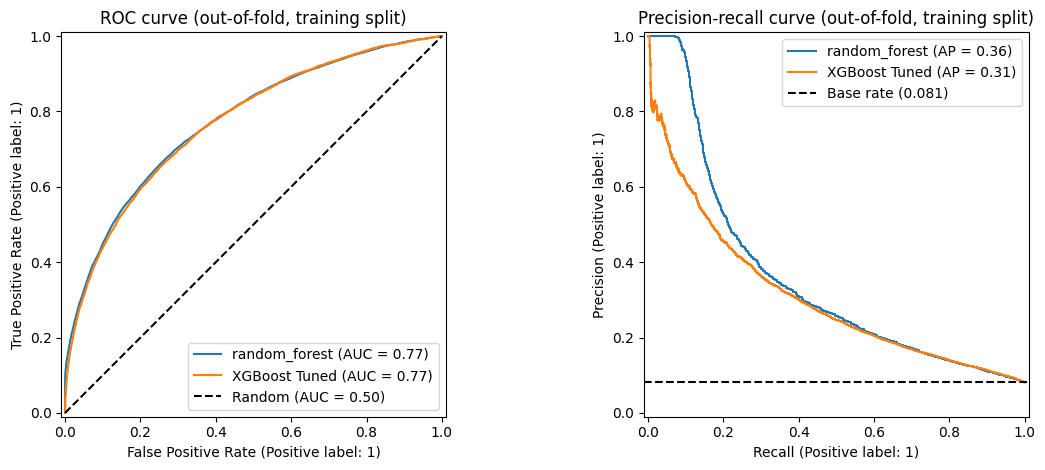

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for name in ["random_forest", "XGBoost Tuned"]:
    RocCurveDisplay.from_predictions(oof["y_true"], oof[name], ax=axes[0], name=name)
    PrecisionRecallDisplay.from_predictions(oof["y_true"], oof[name], ax=axes[1], name=name)

axes[0].plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
axes[0].set_title("ROC curve (out-of-fold, training split)")
axes[0].legend(loc="lower right")

base_rate = oof["y_true"].mean()
axes[1].axhline(base_rate, color="k", linestyle="--", label=f"Base rate ({base_rate:.3f})")
axes[1].set_title("Precision-recall curve (out-of-fold, training split)")
axes[1].legend(loc="upper right")

plt.tight_layout()
figures_dir = "experiments/figures" if os.path.exists("experiments/figures") else "../experiments/figures"
plt.savefig(os.path.join(figures_dir, "06b_shortlist_roc_pr.png"), dpi=100, bbox_inches="tight")
plt.show()


### Precision at fixed recall

For each share of defaulters caught (recall), the best precision each model can reach: of the applicants it flags, how many really default. Out-of-fold, training split only.


In [7]:
from sklearn.metrics import precision_recall_curve


def precision_at_recall(y_true, proba, target_recall):
    precision, recall, _ = precision_recall_curve(y_true, proba)
    return precision[recall >= target_recall].max()


precision_table = pd.DataFrame({
    name: [precision_at_recall(oof["y_true"], oof[name], r) for r in (0.5, 0.6, 0.7)]
    for name in ["random_forest", "XGBoost Tuned"]
}, index=["recall 0.50", "recall 0.60", "recall 0.70"]).round(3)
precision_table


,random_forest,XGBoost Tuned
recall 0.50,0.258,0.246
recall 0.60,0.210,0.205
recall 0.70,0.172,0.169


**Finding:** All nine rows are verified under the same protocol (shared pipeline, `evaluate_model`, stratified 5-fold CV on the training split, threshold 0.5). Under the tiered rule, tier 1 holds Random Forest (untuned) and XGBoost Tuned: their ROC-AUC gap (0.774 vs 0.771) is smaller than Random Forest's standard deviation (0.004), so it is a tie, and PR-AUC puts Random Forest first (0.358 vs 0.307). Random Forest tuned (0.770) is in tier 2 on its own: its gap to the leader (0.0042) is just over one standard deviation (0.0040). The remaining models each form their own tier: XGBoost Baseline (0.763), LightGBM Tuned (0.757), LightGBM Baseline (0.748), Logistic Regression (0.734), Decision Tree (0.708) and Gaussian NB (0.697).

The curves (section 5) show where Random Forest's PR-AUC lead comes from. The ROC curves almost overlap. On the precision-recall curve, Random Forest is far ahead only at low recall: its 600 most confident out-of-fold predictions are 599 defaulters (about 8% of all defaulters), against 427 for XGBoost Tuned. At the recall levels a lender would actually use, the curves are close: precision at recall 0.5 / 0.6 / 0.7 is 0.258 / 0.210 / 0.172 for Random Forest and 0.246 / 0.205 / 0.169 for XGBoost Tuned.

A near-perfect top segment is unusual for data where the best ROC-AUC is 0.77. One possible cause is near-duplicate applications (records that differ only slightly), which a deep, unpruned forest can memorise across folds. Exact duplicates were removed before the split, but near-duplicates were not checked. This has not been tested.

**Decision (proposed):** Random Forest (untuned) and XGBoost Tuned remain the leading candidates, with Random Forest first on PR-AUC. Before the final choice, check whether near-duplicate applications explain Random Forest's high-confidence segment, since that would inflate its PR-AUC lead. The team still needs to confirm the shortlist, agree the operating threshold, and choose the final model before the held-out test set is used.
